In [ ]:
# CODVEDA - LEVEL 1 COMPLETE SOLUTION
# Task 1, 2, 3 ek saath

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error, confusion_matrix

print("--- LEVEL 1 TASK 1: Data Preprocessing ---")
# Iris dataset ko hi raw dataset maan ke preprocessing
iris = load_iris(as_frame=True)
df = iris.frame
print(df.head())
# Missing value check + Scaling
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.iloc[:, :-1])
print("Preprocessing Done, Shape:", df_scaled.shape)

print("\n--- LEVEL 1 TASK 2: Linear Regression ---")
housing = fetch_california_housing(as_frame=True)
df2 = housing.frame
X = df2[['MedInc']]
y = df2['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)
print(f"R2 Score: {r2_score(y_test, pred):.3f}, MSE: {mean_squared_error(y_test, pred):.3f}")

print("\n--- LEVEL 1 TASK 3: KNN Classifier ---")
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
for k in [3,5,7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    print(f"K={k} => Accuracy: {acc*100:.2f}%")

--- LEVEL 1 TASK 1: Data Preprocessing ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
Preprocessing Done, Shape: (150, 4)

--- LEVEL 1 TASK 2: Linear Regression ---
R2 Score: 0.459, MSE: 0.709

--- LEVEL 1 TASK 3: KNN Classifier ---
K=3 => Accuracy: 100.00%
K=5 => Accuracy: 100.00%
K=7 => Accuracy: 96.67%


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.956140350877193


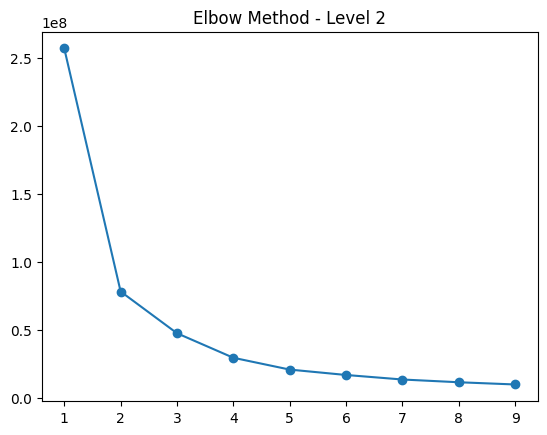

In [2]:
# LEVEL 2 - Logistic + K-Means
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))

inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)
plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method - Level 2")
plt.show()